In [32]:
%matplotlib inline
import numpy as np 
from collections import Counter
from math import log2
import matplotlib.pyplot as plt 
import random 

In [33]:
'''
16 hex numbers
'''
def shannon_hex(hid):
    c = Counter(hid)
    score = - sum([(val / 16) * log2(val / 16) for key, val in c.items()])
    return score

In [34]:
'''
64 binary bits, each can take on the value of 0 or 1
'''
def shannon_bin(hid):
    binary = bin(int(hid, 16))[2:].zfill(64)
    c = Counter(binary)
    score = - sum([(val / 64) * log2(val / 64) for key, val in c.items()])
    return score

In [ ]:
def plot():
    hex_digs = "0123456789abcdef"
    x = range(len(hex_digs))
    addrs = []
    hex_scores = []
    bin_scores = []

    for i in range(0, 16):
        digs = hex_digs[:i+1]
        addr = digs.zfill(16)
        addrs.append(addr)
        hex_scores.append(shannon_hex(addr))
        bin_scores.append(shannon_bin(addr))
        if i == 5:
            print(f"Entropy score for {addr} is {hex_scores[-1]}")
    plt.plot(x, hex_scores, label="hex scores")
    plt.plot(x, bin_scores, label="bin scores")
    plt.plot(x, np.array(hex_scores) / 4, label="hex scores normalized")
    plt.xlabel("Number of unique digits in the address")
    plt.ylabel("Shannon Entropy Score")
    plt.title("Entropy score")
    plt.legend()
    plt.show()

In [36]:
def common_unique():
    # generate a distribution of the count of unique number 
    ntrial = 1000000 # 1 million trials
    hex_digs = list("0123456789abcdef")
    y = []
    entropy_scores = []
    
    for _ in range(ntrial):
        addr = ''.join(random.choices(hex_digs, k=16))
        n_unique_digs = len(set(addr))
        y.append(n_unique_digs)
        entropy_scores.append(shannon_hex(addr))
    
    print(f"Lowest number of unique digits in one address: {min(y)}")
    print(f"Lowest entropy score across all addresses {min(entropy_scores)}")
    plt.hist(y, color='skyblue', edgecolor='black')
    plt.xlabel("Number of unique digit(s)")
    plt.ylabel("Count")
    plt.title("Distribution of unique digit counts in PRNG addresses")
    plt.show()

    plt.hist(entropy_scores, color='skyblue', edgecolor='black')
    plt.xlabel("Entropy score")
    plt.ylabel("Count")
    plt.title("Distribution of shannon entropy scores of PRNG addresses")
    plt.show()

             address                   binary              hexadecimal
    0000000000000001      0.11611507530476972       0.3372900666170139
    0000000000001234       0.3955378064564774        1.311278124459133
    0101010101010101       0.5435644431995964                      1.0
    0f0f0f0f0f0f0f0f                      1.0                      1.0
    0000000011111111       0.5435644431995964                      1.0
    00000000000021f5       0.5435644431995964        1.311278124459133
    0193025300770135       0.9129992135852473       2.6022170014624826
    cec7cb3dce4f938f       0.9652016987500656                    3.125
    f9198bc53b127e76       0.9936507116910404                      3.5
    11235677899bbcef       0.9936507116910404                      3.5
    0123456789abcdef                      1.0                      4.0
    0468ac7db32e9f15                      1.0                      4.0
entropy score for 0000000000012345 is 1.6216407621868583


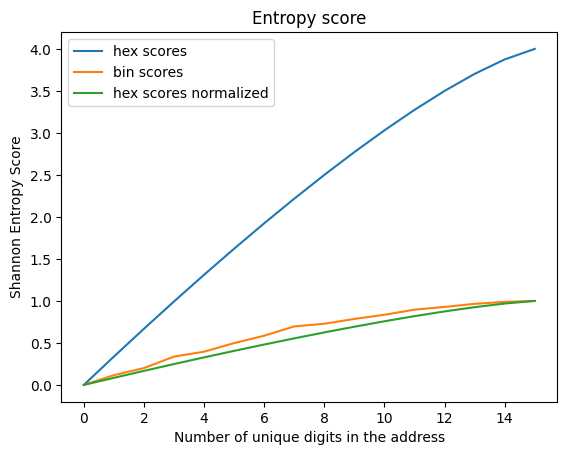

Lowest number of unique digits in one address: 4
Lowest entropy score across all addresses 1.75


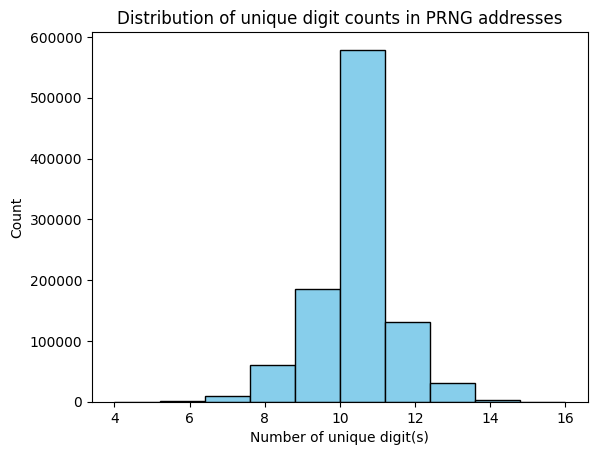

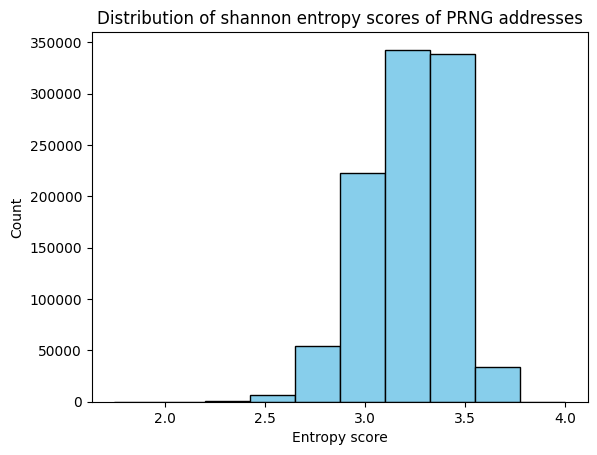

In [37]:
def main():
    hex_host_ids = [
        "0000000000000001", # least random looking
        "0000000000001234", # least random looking
        "0101010101010101", # location
        "0f0f0f0f0f0f0f0f", # location
        ''.join(sorted(list("0101010101010101"))), # same as above but sorted
        "00000000000021f5", # irl example
        "0193025300770135", # irl example of extended v4 address
        "cec7cb3dce4f938f", # made by PRNG
        "f9198bc53b127e76", # made by PRNG
        ''.join(sorted(list("f9198bc53b127e76"))), # same as above but sorted
        "0123456789abcdef", # manual string hitting all hex numbers
        "0468ac7db32e9f15", # same as above but in different order
    ]
    print(f"{"address":>20}{"binary":>25}{"hexadecimal":>25}")
    for hid in hex_host_ids:
        print(f"{hid:>20}{shannon_bin(hid):>25}{shannon_hex(hid):>25}")
    
    plot()
    common_unique()

if __name__ == "__main__":
    main()